In [31]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
df = pd.read_csv('Clean_dataset_nibong_10062026.csv', index_col=0, parse_dates=True) #kena ada hujung tu as jadi index depan (tulang)

In [33]:
data_values = df.values

Can change based on the LoopBack

In [34]:
#train_size = int(len(data_values) * 0.7)
#val_size   = int(len(data_values) * 0.1)

train_size = int(len(data_values) * 0.6)
val_size   = int(len(data_values) * 0.2)

train_data = data_values[:train_size]
val_data   = data_values[train_size:train_size + val_size]
test_data  = data_values[train_size + val_size:]

In [35]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
scaled_val   = scaler.transform(val_data)
scaled_test  = scaler.transform(test_data)

In [36]:
#def create_multivariate_dataset(dataset, look_back=12, target_col=4):
    #X, Y = [], []
    #for i in range(len(dataset) - look_back):
        #X.append(dataset[i:(i + look_back), :])
        #Y.append(dataset[i + look_back, target_col])
    #return np.array(X), np.array(Y)

Horizon

In [37]:
#horizon
def create_multivariate_dataset(dataset, look_back=12, forecast_horizon=1, target_col=4):
    X, Y = [], []
    for i in range(len(dataset) - look_back - forecast_horizon):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back : i + look_back + forecast_horizon, target_col])
    return np.array(X), np.array(Y)

In [38]:
#look_back = 12
#X_train, y_train = create_multivariate_dataset(scaled_train, look_back, target_col=4)
#X_val, y_val     = create_multivariate_dataset(scaled_val,   look_back, target_col=4)
#X_test, y_test   = create_multivariate_dataset(scaled_test,  look_back, target_col=4)

Horizon

In [39]:
forecast_horizon = 1

X_train, y_train = create_multivariate_dataset(scaled_train, look_back=12, forecast_horizon=forecast_horizon)
X_val, y_val     = create_multivariate_dataset(scaled_val,   look_back=12, forecast_horizon=forecast_horizon)
X_test, y_test   = create_multivariate_dataset(scaled_test,  look_back=12, forecast_horizon=forecast_horizon)

Continue

In [40]:
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")

X_train : (6158, 12, 6)
y_train : (6158, 1)


In [41]:
np.savez('dataset_LSTM_10062026_Multi_5M_version3.npz', X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
with open('scaler_multivariate_LSTM_10062026_5M_version3.pkl', 'wb')as f:
    pickle.dump(scaler, f)

ARCHITECTURE LSTM

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [43]:
model = Sequential()

In [44]:
#1st layer
model.add(LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

c:\Users\haziq\anaconda3\envs\Machine\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [45]:
#2nd layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

In [46]:
#model.add(Dense(units=1))
model.add(Dense(units=forecast_horizon))  # e.g. 288 for 1 day
model.compile(optimizer='adam', loss='mean_absolute_error')

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 100)        │        42,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,051 (285.36 KB)

 Trainable params: 73,051 (285.36 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
#callbacks = [
    #EarlyStopping( patience=10, restore_best_weights=True),
    #ModelCheckpoint('top2_model.keras', save_best_only=True)
#]

In [48]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',        # ← add this
        patience=10,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        'top_model_version_5M_version3.keras',
        monitor='val_loss',        # ← add this
        save_best_only=True
    )
]

In [49]:
# Train
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    shuffle=False,
    callbacks=callbacks
)

Epoch 1/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0441 - val_loss: 0.0166
Epoch 2/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0317 - val_loss: 0.0159
Epoch 3/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0258 - val_loss: 0.0118
Epoch 4/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0225 - val_loss: 0.0107
Epoch 5/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0206 - val_loss: 0.0100
Epoch 6/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0189 - val_loss: 0.0095
Epoch 7/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0168 - val_loss: 0.0089
Epoch 8/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0163 - val_loss: 0.0086
Epoch 9/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0158 - val_loss: 0.0087
Epoch 10/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0157 - val_loss: 0.0085
Epoch 11/150
193/193 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0151 - val_loss: 0.0084
Epoch 12/150
193/193 ━━━━━━━━━━━━

In [50]:
import matplotlib.pyplot as plt

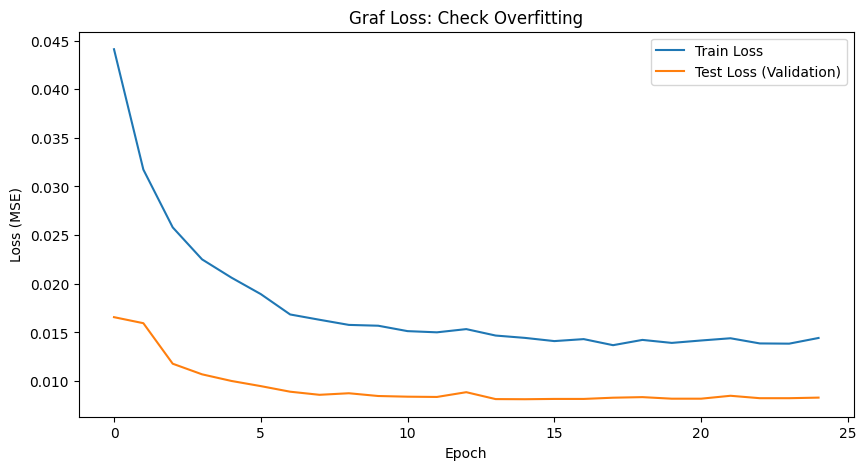

In [51]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss (Validation)')
plt.title('Graf Loss: Check Overfitting')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [52]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [53]:
#def inverse_pm25(scaler, y_val,n_features):
    #dummy = np.zeros((len(y_val),n_features))
    #dummy[:, 4] = y_val.flatten()
    #return scaler.inverse_transform(dummy)[:,4]

In [54]:
def inverse_pm25(scaler, y_multi, n_features):
    results = []
    for row in y_multi:
        dummy = np.zeros((len(row), n_features))
        dummy[:, 4] = row
        results.append(scaler.inverse_transform(dummy)[:, 4])
    return np.array(results)

In [55]:
n_features = X_train.shape[2]  # auto-detects correct number

y_train_actual = inverse_pm25(scaler, y_train,n_features)
y_train_pred   = inverse_pm25(scaler, train_predict,n_features)
y_test_actual  = inverse_pm25(scaler, y_test,n_features)
y_test_pred    = inverse_pm25(scaler, test_predict,n_features)

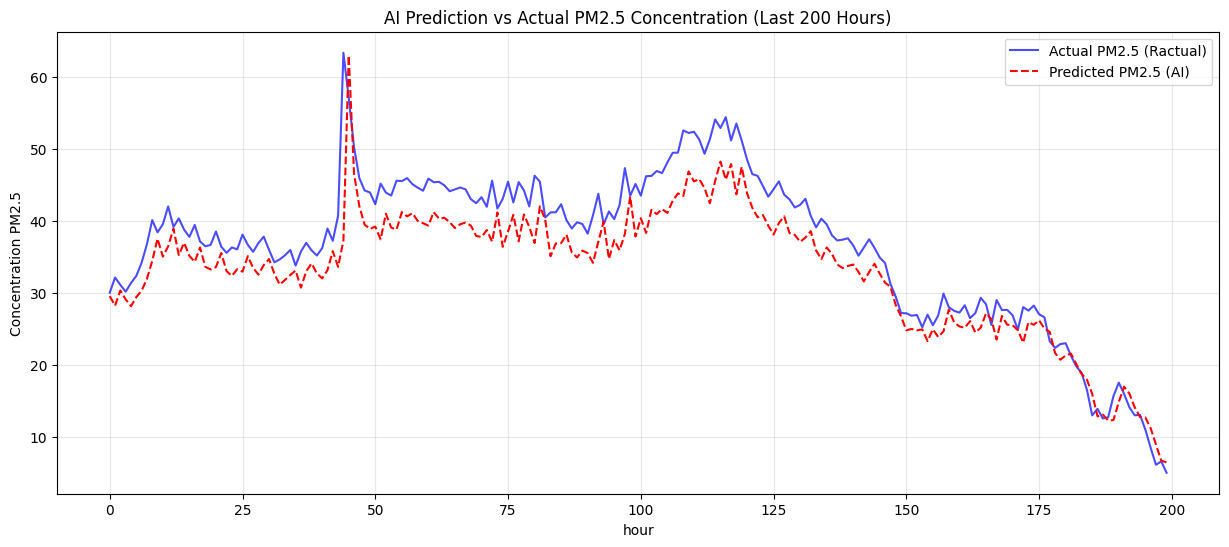

In [56]:
plt.figure(figsize=(15, 6))
plt.plot(y_test_actual[-200:], label='Actual PM2.5 (Ractual)', color='blue', alpha=0.7)
plt.plot(y_test_pred[-200:], label='Predicted PM2.5 (AI)', color='red', linestyle='--')
plt.title('AI Prediction vs Actual PM2.5 Concentration (Last 200 Hours)')
plt.xlabel('hour')
plt.ylabel('Concentration PM2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

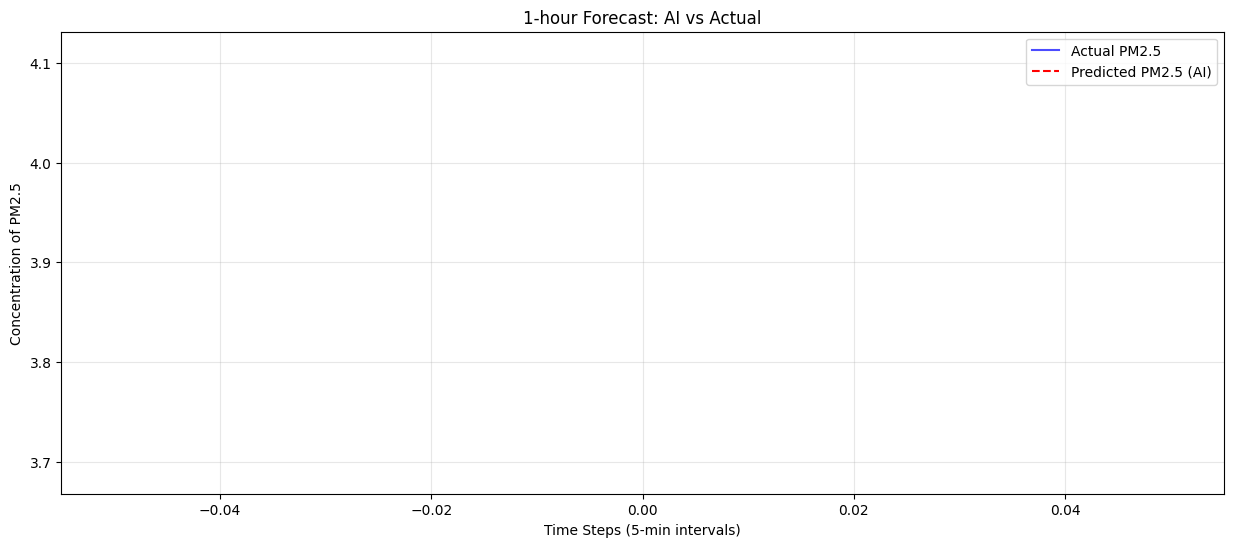

In [57]:
sample_idx = 150   # pick which test sample to visualize

plt.figure(figsize=(15, 6))
plt.plot(y_test_actual[sample_idx], label='Actual PM2.5', color='blue', alpha=0.7)
plt.plot(y_test_pred[sample_idx], label='Predicted PM2.5 (AI)', color='red', linestyle='--')
plt.title('1-hour Forecast: AI vs Actual')
plt.xlabel('Time Steps (5-min intervals)')
plt.ylabel('Concentration of PM2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [58]:
mae = mean_absolute_error(y_test_actual, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
r2 = r2_score(y_test_actual, y_test_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

MAE: 1.0589
RMSE: 2.0801
R2 Score: 0.9606


In [59]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score

def plot_diagnostic_graphs(y_true, y_pred, model_name, phase_name="Phase 1: Optimal (5 minutes)"):
    # 1. Pastikan data dalam bentuk 1D array supaya tak berlapis
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # 2. Kira markah R2 untuk dipaparkan secara automatik
    r2 = r2_score(y_true, y_pred)
    
    # 3. Kira Ralat (Residuals) = Nilai Sebenar - Nilai Tekaan
    residuals = y_true - y_pred
    
    # 4. Setup Figure (1 Baris, 2 Lajur)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- GRAF 1 (KIRI): SCATTER PLOT ---
    axes[0].scatter(y_true, y_pred, alpha=0.5, color='#1f77b4', edgecolor='k')
    
    # Buat garisan rujukan ideal (Merah Putus-putus)
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction Line')
    
    axes[0].set_title(f'Prediction Scatter Plot\n(R² Score: {r2:.4f})', fontsize=14, fontweight='bold', pad=10)
    axes[0].set_xlabel('Actual PM2.5 Concentration (µg/m³)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Predicted PM2.5 Concentration (µg/m³)', fontsize=12, fontweight='bold')
    axes[0].grid(True, linestyle=':', alpha=0.6)
    axes[0].legend()
    
    # --- GRAF 2 (KANAN): RESIDUAL HISTOGRAM ---
    sns.histplot(residuals, kde=True, ax=axes[1], color='#9467bd', bins=30)
    axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error Baseline')
    
    axes[1].set_title(f'Residual Error Distribution\n(Mean Error: {np.mean(residuals):.4f})', fontsize=14, fontweight='bold', pad=10)
    axes[1].set_xlabel('Prediction Error (Actual - Predicted)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[1].grid(True, linestyle=':', alpha=0.6)
    axes[1].legend()
    
    # 5. Kemaskan susunan keseluruhan
    plt.tight_layout()
    plt.suptitle(f'Diagnostic Validation: {model_name} [{phase_name}]', fontsize=16, fontweight='bold', y=1.05)
    
    # 6. Simpan gambar secara automatik
    filename = f"Fig_4_X_Diagnostic_{model_name.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"[BERJAYA] Graf Diagnostik untuk {model_name} telah disimpan sebagai {filename}!")

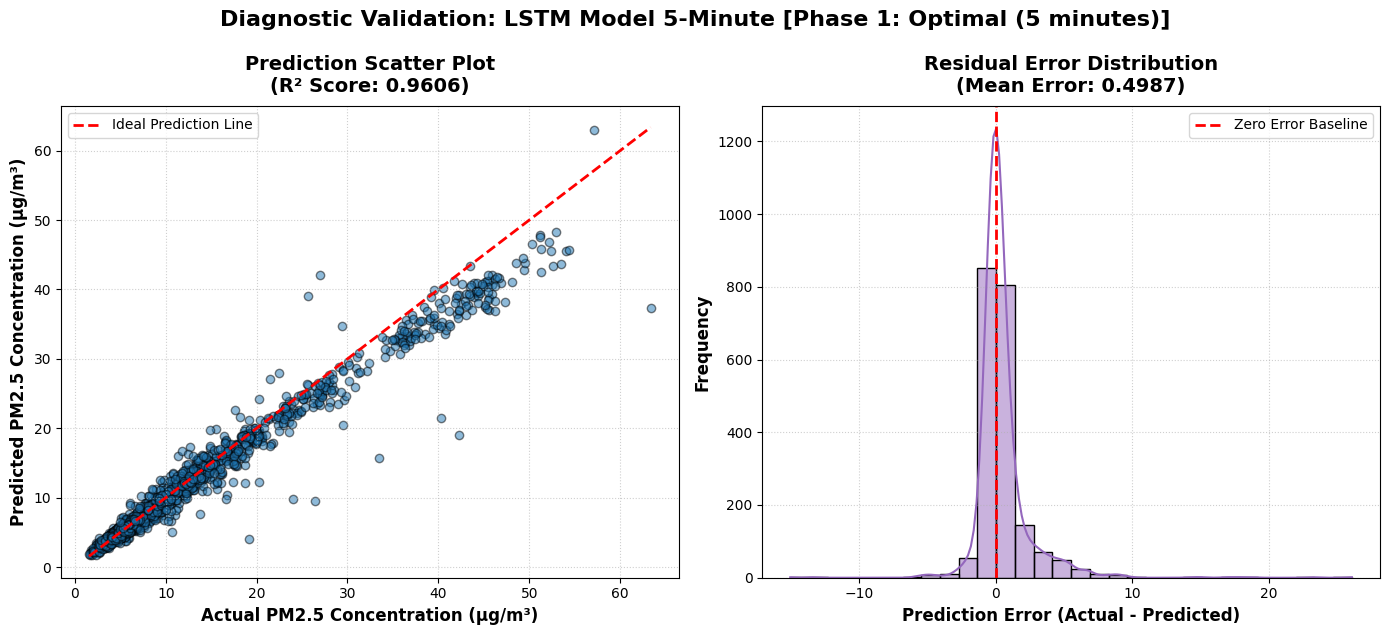

[BERJAYA] Graf Diagnostik untuk LSTM Model 5-Minute telah disimpan sebagai Fig_4_X_Diagnostic_LSTM_Model_5-Minute.png!


In [60]:
plot_diagnostic_graphs(y_test_actual, y_test_pred, model_name="LSTM Model 5-Minute")